# Notebook 41 - Fix `get_fasMask` Parity

Goal: use the MATLAB intermediate mask export from Notebook 36 to isolate the fascicle-mask branch:

1. Load the exported MATLAB masks from the existing `.mat` files.
2. Compare each stage pixel by pixel: aponeurosis masks, fascicle threshold/subtraction, ellipse mask, and final `fascicle_masked`.
3. Rebuild only the `get_fasMask` ellipse in Python from MATLAB `super_vec` / `deep_vec` and verify Dice > 0.99.
4. Feed the rebuilt mask directly into the already validated `dohough` path from Notebook 40 and check alpha convergence.
5. Run `scripts/compare_ultratimtrack_parity.py` on the 9 exported frames to generate `parity_metrics.csv` with alpha, phi, faslen, gamma, betha, super_pos, and deep_pos metrics.

## Reference-State Note

The Notebook 36 mask export carries its own saved same-mask alpha. `slow_low_2.mat` also has `Fdat.geofeatures.alpha` for those frames. If those two MATLAB references disagree, this notebook treats it as MATLAB reference-state drift and keeps the two gates separate:

- `get_fasMask` / same-mask gate: compared against the Notebook 36 exported masks and exported alpha.
- Full geofeature gate: generated by `compare_ultratimtrack_parity.py` against `slow_low_2.mat`.

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "ultrasound_tracker").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ultrasound_tracker.matlab_compat import load_matlab_result, extract_geofeature_arrays
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough, fascicle_ellipse_mask

plt.style.use("dark_background")
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=RuntimeWarning)
print("Project root:", PROJECT_ROOT)

Project root: /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
MATLAB_RESULT = PROJECT_ROOT / "data/matlab/slow_low_2.mat"
VIDEO_PATH = PROJECT_ROOT / "data/raw/Test2.mp4"
UTT_EXPORT = Path("/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat")
MATLAB_MASK_EXPORT_N36 = PROJECT_ROOT / "results/notebook36_mask_parity/matlab_intermediate_masks_notebook36.mat"
PYTHON_MASK_CACHE_N36 = PROJECT_ROOT / "results/notebook36_mask_parity/python_intermediate_masks_notebook36.npz"
NOTEBOOK38_NPZ = PROJECT_ROOT / "results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz"

OUT_DIR = PROJECT_ROOT / "results/notebook41_fix_get_fas_mask_parity"
OUT_FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_STAGE = OUT_DIR / "notebook41_stage_pixel_scores.csv"
OUT_GATE = OUT_DIR / "notebook41_get_fas_mask_dohough_gate.csv"
OUT_PARITY = OUT_DIR / "parity_metrics.csv"
OUT_FIG = OUT_FIG_DIR / "notebook41_worst_current_mask_vs_rebuilt.png"

for label, p in {
    "current MATLAB result": MATLAB_RESULT,
    "video": VIDEO_PATH,
    "UTT numeric export": UTT_EXPORT,
    "Notebook 36 MATLAB mask export": MATLAB_MASK_EXPORT_N36,
    "Notebook 36 Python cache": PYTHON_MASK_CACHE_N36,
    "Notebook 38 sequence NPZ": NOTEBOOK38_NPZ,
}.items():
    print(f"{label:34s}", "OK" if p.exists() else "missing", p)

mat = load_matlab_result(MATLAB_RESULT)
current_geo = extract_geofeature_arrays(mat)
utt = loadmat(UTT_EXPORT, simplify_cells=True)["UTT_numeric_export"]
fas_parms = utt["parms"]["fas"]

mask_export = loadmat(MATLAB_MASK_EXPORT_N36, simplify_cells=True)
matlab_entries = np.asarray(mask_export["M"], dtype=object).reshape(-1).tolist()
frames = np.asarray([int(entry["frame0"]) for entry in matlab_entries], dtype=np.int64)
mask_by_frame = {int(entry["frame0"]): entry for entry in matlab_entries}

python_cache = np.load(PYTHON_MASK_CACHE_N36, allow_pickle=True) if PYTHON_MASK_CACHE_N36.exists() else None
cache_index_by_frame = {}
if python_cache is not None:
    for i in range(len(np.asarray(python_cache["frames0"]).reshape(-1))):
        cache_index_by_frame[int(np.asarray(python_cache[f"frame0_{i}"]).reshape(-1)[0])] = i

context = pd.DataFrame([
    {"item": "exported frame count", "value": len(frames)},
    {"item": "exported frames", "value": frames.tolist()},
    {"item": "fas.range", "value": np.asarray(fas_parms["range"]).reshape(-1).tolist()},
    {"item": "fas.thetares", "value": float(fas_parms["thetares"])},
    {"item": "fas.rhores", "value": float(fas_parms["rhores"])},
    {"item": "fas.npeaks", "value": int(fas_parms["npeaks"])},
])
display(context)

current MATLAB result              OK /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat
video                              OK /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4
UTT numeric export                 OK /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat
Notebook 36 MATLAB mask export     OK /Users/grosbedou/PycharmProjects/NDORMS/results/notebook36_mask_parity/matlab_intermediate_masks_notebook36.mat
Notebook 36 Python cache           OK /Users/grosbedou/PycharmProjects/NDORMS/results/notebook36_mask_parity/python_intermediate_masks_notebook36.npz
Notebook 38 sequence NPZ           OK /Users/grosbedou/PycharmProjects/NDORMS/results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz


,item,value
0,exported frame count,9
1,exported frames,"[0, 122, 533, 691, 955, 1066, 1600, 2133, 2665]"
2,fas.range,"[5, 60]"
3,fas.thetares,0.5
4,fas.rhores,1.0
5,fas.npeaks,10


In [3]:
def as_bool(x):
    return np.asarray(x).astype(bool)


def as_float(x):
    return np.asarray(x, dtype=np.float64)


def scalar(x):
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    return float(arr[0]) if arr.size else np.nan


def matlab_round_positive(x):
    return np.floor(np.asarray(x, dtype=np.float64) + 0.5).astype(int)


def mask_scores(reference, estimate):
    ref = as_bool(reference)
    est = as_bool(estimate)
    if ref.shape != est.shape:
        return {
            "iou": np.nan,
            "dice": np.nan,
            "mae": np.nan,
            "matlab_density": float(np.mean(ref)),
            "python_density": float(np.mean(est)),
            "xor_px": np.nan,
        }
    inter = np.logical_and(ref, est).sum()
    union = np.logical_or(ref, est).sum()
    denom = ref.sum() + est.sum()
    xor = np.logical_xor(ref, est).sum()
    return {
        "iou": float(inter / union) if union else np.nan,
        "dice": float(2 * inter / denom) if denom else np.nan,
        "mae": float(np.mean(ref != est)),
        "matlab_density": float(np.mean(ref)),
        "python_density": float(np.mean(est)),
        "xor_px": int(xor),
    }


def cached_value(frame, key):
    if python_cache is None or int(frame) not in cache_index_by_frame:
        return None
    idx = cache_index_by_frame[int(frame)]
    cache_key = f"{key}_{idx}"
    return python_cache[cache_key] if cache_key in python_cache.files else None


def make_params(radius):
    return DoHoughParams(
        houghangles=str(fas_parms["houghangles"]),
        angle_range=tuple(np.asarray(fas_parms["range"], dtype=float).reshape(-1)),
        thetares=float(fas_parms["thetares"]),
        rhores=float(fas_parms["rhores"]),
        emask_radius=tuple(np.asarray(radius, dtype=float).reshape(-1)),
        npeaks=int(fas_parms["npeaks"]),
        replace_diagonal_bias=True,
    )


def rebuild_get_fas_mask(entry):
    super_vec = as_float(entry["super_vec"]).reshape(-1)
    deep_vec = as_float(entry["deep_vec"]).reshape(-1)
    mean_super = matlab_round_positive(np.nanmean(super_vec))
    mean_deep = matlab_round_positive(np.nanmean(deep_vec))
    emask, radius = fascicle_ellipse_mask(as_bool(entry["fas_thres"]).shape, mean_super, mean_deep)
    fascicle_masked = as_bool(entry["fas_thres"]) & emask
    return {
        "Emask": emask,
        "fascicle_masked": fascicle_masked,
        "Emask_radius": np.asarray(radius, dtype=np.float64),
        "mean_super_depth": float(mean_super),
        "mean_deep_depth": float(mean_deep),
    }


def first_last_from_vector(vec):
    arr = as_float(vec).reshape(-1)
    return float(arr[0]), float(arr[-1])

In [4]:
stage_rows = []
stages = [
    ("apo_thres", "apo_thres"),
    ("apo_super", "apo_super"),
    ("apo_deep", "apo_deep"),
    ("fas_thres_raw", "fas_thres_raw"),
    ("fas_thres_after_subtraction", "fas_thres"),
    ("ellipse_mask", "Emask"),
    ("fascicle_masked", "fascicle_masked"),
]

rebuilt_by_frame = {}
for entry in matlab_entries:
    frame = int(entry["frame0"])
    rebuilt = rebuild_get_fas_mask(entry)
    rebuilt_by_frame[frame] = rebuilt

    for stage, key in stages:
        py = cached_value(frame, key)
        if py is not None:
            scores = mask_scores(entry[key], py)
            stage_rows.append({
                "frame": frame,
                "mode": "current_python_nb36_cache",
                "stage": stage,
                **scores,
            })

    for stage, key in [("ellipse_mask", "Emask"), ("fascicle_masked", "fascicle_masked")]:
        scores = mask_scores(entry[key], rebuilt[key])
        stage_rows.append({
            "frame": frame,
            "mode": "rebuilt_get_fasMask_from_matlab_fas_thres",
            "stage": stage,
            **scores,
        })

stage_df = pd.DataFrame(stage_rows)
stage_df.to_csv(OUT_STAGE, index=False)
summary_df = (
    stage_df.groupby(["mode", "stage"], as_index=False)
    .agg(
        n=("frame", "count"),
        mean_dice=("dice", "mean"),
        min_dice=("dice", "min"),
        mean_iou=("iou", "mean"),
        max_xor_px=("xor_px", "max"),
    )
    .sort_values(["mode", "stage"])
)

display(summary_df.round(6))
print("Stage scores:", OUT_STAGE)

,mode,stage,n,mean_dice,min_dice,mean_iou,max_xor_px
0,current_python_nb36_cache,apo_deep,9,0.8128,0.7999,0.6848,6858
1,current_python_nb36_cache,apo_super,9,0.8358,0.8266,0.7179,5298
2,current_python_nb36_cache,apo_thres,9,0.8370,0.8238,0.7198,42834
3,current_python_nb36_cache,ellipse_mask,9,0.9966,0.9898,0.9931,2970
4,current_python_nb36_cache,fas_thres_after_subtraction,9,0.9146,0.9003,0.8427,16435
5,current_python_nb36_cache,fas_thres_raw,9,0.9146,0.9003,0.8427,16435
6,current_python_nb36_cache,fascicle_masked,9,0.8970,0.8720,0.8135,6860
7,rebuilt_get_fasMask_from_matlab_fas_thres,ellipse_mask,9,0.9997,0.9996,0.9993,128
8,rebuilt_get_fasMask_from_matlab_fas_thres,fascicle_masked,9,0.9998,0.9997,0.9995,18


Stage scores: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook41_fix_get_fas_mask_parity/notebook41_stage_pixel_scores.csv


In [5]:
gate_rows = []
for entry in matlab_entries:
    frame = int(entry["frame0"])
    mat_alpha_export = scalar(entry["alpha"])
    current_alpha = float(current_geo["alpha_deg"][frame]) if frame < len(current_geo["alpha_deg"]) else np.nan

    rebuilt = rebuilt_by_frame[frame]
    same_mask_params = make_params(entry["Emask_radius"])
    rebuilt_params = make_params(rebuilt["Emask_radius"])

    same_mask_hough = dohough(as_bool(entry["fascicle_masked"]), same_mask_params)
    rebuilt_hough = dohough(rebuilt["fascicle_masked"], rebuilt_params)

    final_scores = mask_scores(entry["fascicle_masked"], rebuilt["fascicle_masked"])
    emask_scores = mask_scores(entry["Emask"], rebuilt["Emask"])

    gate_rows.append({
        "frame": frame,
        "matlab_export_alpha": mat_alpha_export,
        "current_slow_low_2_alpha": current_alpha,
        "current_minus_export_alpha": current_alpha - mat_alpha_export if np.isfinite(current_alpha) else np.nan,
        "same_mask_dohough_alpha": float(same_mask_hough["alpha"]),
        "rebuilt_get_fasMask_alpha": float(rebuilt_hough["alpha"]),
        "same_mask_alpha_error_to_export": float(same_mask_hough["alpha"] - mat_alpha_export),
        "rebuilt_alpha_error_to_export": float(rebuilt_hough["alpha"] - mat_alpha_export),
        "rebuilt_alpha_error_to_current_matlab": float(rebuilt_hough["alpha"] - current_alpha) if np.isfinite(current_alpha) else np.nan,
        "rebuilt_emask_dice": emask_scores["dice"],
        "rebuilt_fascicle_masked_dice": final_scores["dice"],
        "rebuilt_fascicle_masked_xor_px": final_scores["xor_px"],
        "rebuilt_mean_super_depth": rebuilt["mean_super_depth"],
        "rebuilt_mean_deep_depth": rebuilt["mean_deep_depth"],
    })

gate_df = pd.DataFrame(gate_rows)
gate_df.to_csv(OUT_GATE, index=False)
display(gate_df.round(6))

passed_mask = bool(gate_df["rebuilt_fascicle_masked_dice"].min() > 0.99)
passed_alpha = bool(np.nanmax(np.abs(gate_df["rebuilt_alpha_error_to_export"])) <= 0.5)
state_drift = gate_df[np.abs(gate_df["current_minus_export_alpha"]) > 0.5]["frame"].astype(int).tolist()

status = pd.DataFrame([
    {"gate": "rebuilt fascicle_masked Dice > 0.99", "passed": passed_mask, "value": gate_df["rebuilt_fascicle_masked_dice"].min()},
    {"gate": "rebuilt alpha within 0.5 deg of NB36 export", "passed": passed_alpha, "value": np.nanmax(np.abs(gate_df["rebuilt_alpha_error_to_export"]))},
    {"gate": "frames where slow_low_2 alpha differs from NB36 export by >0.5 deg", "passed": len(state_drift) == 0, "value": state_drift},
])
display(status)
print("get_fasMask/dohough gate:", OUT_GATE)

,frame,matlab_export_alpha,current_slow_low_2_alpha,current_minus_export_alpha,same_mask_dohough_alpha,rebuilt_get_fasMask_alpha,same_mask_alpha_error_to_export,rebuilt_alpha_error_to_export,rebuilt_alpha_error_to_current_matlab,rebuilt_emask_dice,rebuilt_fascicle_masked_dice,rebuilt_fascicle_masked_xor_px,rebuilt_mean_super_depth,rebuilt_mean_deep_depth
0,0,18.5,18.5,0.0,18.5,18.5,0.0,0.0,0.0,0.9996,0.9997,17,45.0,320.0
1,122,15.0,32.0,17.0,15.0,15.0,0.0,0.0,-17.0,0.9997,0.9998,12,45.0,316.0
2,533,19.5,19.5,0.0,19.5,19.5,0.0,0.0,0.0,0.9996,0.9997,18,44.0,319.0
3,691,16.5,34.0,17.5,16.5,16.5,0.0,0.0,-17.5,0.9997,0.9998,9,45.0,305.0
4,955,14.5,32.0,17.5,14.5,14.5,0.0,0.0,-17.5,0.9998,0.9998,8,43.0,312.0
5,1066,20.0,20.5,0.5,19.5,19.5,-0.5,-0.5,-1.0,0.9996,0.9997,16,44.0,319.0
6,1600,19.0,20.0,1.0,19.0,19.0,0.0,0.0,-1.0,0.9996,0.9997,16,44.0,319.0
7,2133,19.5,20.0,0.5,19.5,19.5,0.0,0.0,-0.5,0.9996,0.9998,15,44.0,320.0
8,2665,19.5,20.5,1.0,19.5,19.5,0.0,0.0,-1.0,0.9996,0.9998,14,44.0,319.0


,gate,passed,value
0,rebuilt fascicle_masked Dice > 0.99,True,0.9997
1,rebuilt alpha within 0.5 deg of NB36 export,True,0.5
2,frames where slow_low_2 alpha differs from NB3...,False,"[122, 691, 955, 1600, 2665]"


get_fasMask/dohough gate: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook41_fix_get_fas_mask_parity/notebook41_get_fas_mask_dohough_gate.csv


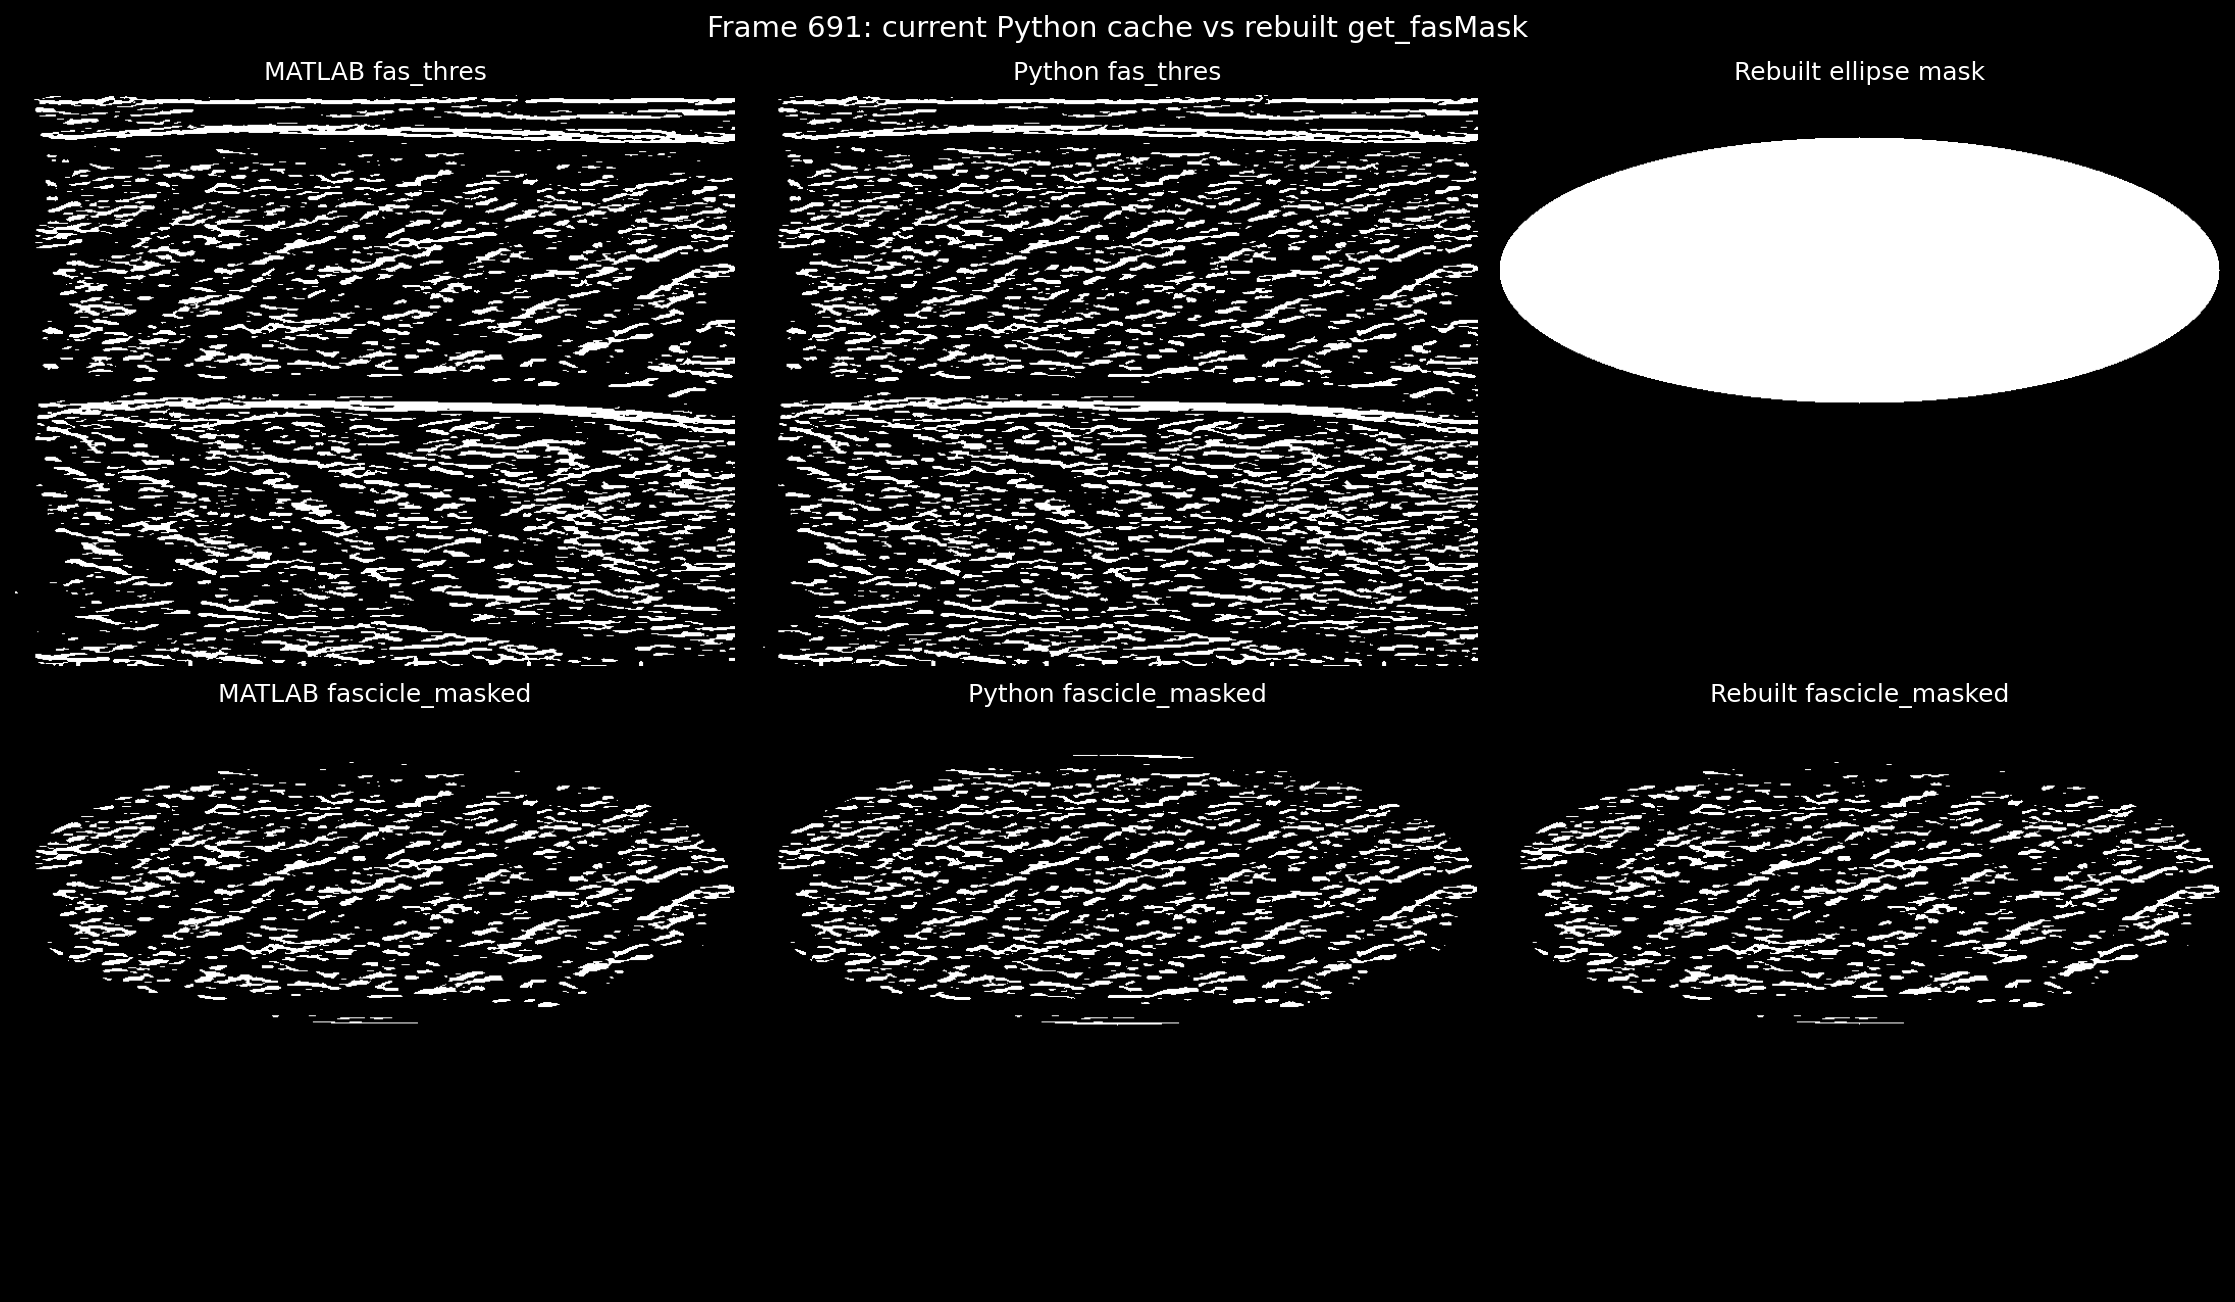

Figure: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook41_fix_get_fas_mask_parity/figures/notebook41_worst_current_mask_vs_rebuilt.png


In [6]:
worst_row = (
    stage_df[(stage_df["mode"] == "current_python_nb36_cache") & (stage_df["stage"] == "fascicle_masked")]
    .sort_values("dice")
    .head(1)
)
if not worst_row.empty:
    worst_frame = int(worst_row.iloc[0]["frame"])
    entry = mask_by_frame[worst_frame]
    rebuilt = rebuilt_by_frame[worst_frame]
    py_fas_thres = cached_value(worst_frame, "fas_thres")
    py_emask = cached_value(worst_frame, "Emask")
    py_final = cached_value(worst_frame, "fascicle_masked")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f"Frame {worst_frame}: current Python cache vs rebuilt get_fasMask", fontsize=14)
    panels = [
        ("MATLAB fas_thres", entry["fas_thres"]),
        ("Python fas_thres", py_fas_thres),
        ("Rebuilt ellipse mask", rebuilt["Emask"]),
        ("MATLAB fascicle_masked", entry["fascicle_masked"]),
        ("Python fascicle_masked", py_final),
        ("Rebuilt fascicle_masked", rebuilt["fascicle_masked"]),
    ]
    for ax, (title, image) in zip(axes.ravel(), panels):
        ax.imshow(as_bool(image), cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(OUT_FIG)))
    print("Figure:", OUT_FIG)
else:
    print("No current Python cache rows available for a visual panel.")

In [7]:
cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts/compare_ultratimtrack_parity.py"),
    "--matlab-result",
    str(MATLAB_RESULT),
    "--python-utt",
    str(NOTEBOOK38_NPZ),
    "--python-timtrack",
    str(NOTEBOOK38_NPZ),
    "--video",
    str(VIDEO_PATH),
    "--frames",
    *[str(int(f)) for f in frames],
    "--out-csv",
    str(OUT_PARITY),
]
print(" ".join(cmd))
run = subprocess.run(cmd, cwd=str(PROJECT_ROOT), text=True, capture_output=True)
print(run.stdout)
if run.stderr:
    print(run.stderr)
if run.returncode != 0:
    raise RuntimeError(f"compare_ultratimtrack_parity.py failed with exit code {run.returncode}")

parity_df = pd.read_csv(OUT_PARITY)
display(parity_df.round(4))
print("Parity metrics:", OUT_PARITY)

/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/compare_ultratimtrack_parity.py --matlab-result /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat --python-utt /Users/grosbedou/PycharmProjects/NDORMS/results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz --python-timtrack /Users/grosbedou/PycharmProjects/NDORMS/results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz --video /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4 --frames 0 122 533 691 955 1066 1600 2133 2665 --out-csv /Users/grosbedou/PycharmProjects/NDORMS/results/notebook41_fix_get_fas_mask_parity/parity_metrics.csv


MATLAB result: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat
Python final:  /Users/grosbedou/PycharmProjects/NDORMS/results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz
Python TimTrack-like: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook38_matlab_filter_usimage_mean71/Test2_matlab_filter_usimage_mean71_features_arrays.npz
image_depth_mm=50.7
image_height_px=562
mm_per_pixel=0.09021352
frames=[0, 122, 533, 691, 955, 1066, 1600, 2133, 2665]

comparison                                n       bias        mae       rmse     corr
-------------------------------------------------------------------------------------
final_FL_mm                               9    13.7104    14.3287    23.6718  -0.9223
final_PEN_deg                             9    -5.5916     5.5916     8.8545  -0.9338
final_ANG_deg                             9    -5.4157     5.5524     9.0382  -0.9437
timtrack_alpha_deg                        9  

,comparison,n,bias,mae,rmse,corr
0,final_FL_mm,9,13.7104,14.3287,23.6718,-0.9223
1,final_PEN_deg,9,-5.5916,5.5916,8.8545,-0.9338
2,final_ANG_deg,9,-5.4157,5.5524,9.0382,-0.9437
3,timtrack_alpha_deg,9,-6.1111,6.1111,10.2144,-0.9375
4,timtrack_phi_vs_python_pen_deg,9,-5.9173,5.9600,10.0480,-0.9472
5,timtrack_formula_faslen_px,9,160.4210,165.6065,277.4016,-0.9188
6,timtrack_gamma_deep_apo_deg,9,-0.0714,0.1245,0.1467,0.9634
7,timtrack_betha_super_apo_deg,9,-0.1938,0.3408,0.4072,0.2884
8,timtrack_super_pos_y1,9,-0.8837,3.8434,4.3913,-0.0554
9,timtrack_super_pos_y2,9,0.5952,1.0589,1.3872,0.6160


Parity metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook41_fix_get_fas_mask_parity/parity_metrics.csv


In [8]:
tolerances = {
    "timtrack_alpha_deg": 0.5,
    "timtrack_phi_vs_python_pen_deg": 0.5,
    "timtrack_formula_faslen_px": 5.0,
    "timtrack_gamma_deep_apo_deg": 0.5,
    "timtrack_betha_super_apo_deg": 0.5,
    "timtrack_super_pos_y1": 5.0,
    "timtrack_super_pos_y2": 5.0,
    "timtrack_deep_pos_y1": 5.0,
    "timtrack_deep_pos_y2": 5.0,
}

tol_df = parity_df[parity_df["comparison"].isin(tolerances)].copy()
tol_df["tolerance"] = tol_df["comparison"].map(tolerances)
tol_df["mae_within_tolerance"] = tol_df["mae"] <= tol_df["tolerance"]
tol_df["rmse_within_tolerance"] = tol_df["rmse"] <= tol_df["tolerance"]
display(tol_df.round(4))

if not tol_df["mae_within_tolerance"].all():
    failed = tol_df.loc[~tol_df["mae_within_tolerance"], "comparison"].tolist()
    display(Markdown("**Full 9-frame geofeature gate still fails MAE tolerance for:** " + ", ".join(failed)))
else:
    display(Markdown("**Full 9-frame geofeature gate passes the configured MAE tolerances.**"))

,comparison,n,bias,mae,rmse,corr,tolerance,mae_within_tolerance,rmse_within_tolerance
3,timtrack_alpha_deg,9,-6.1111,6.1111,10.2144,-0.9375,0.5,False,False
4,timtrack_phi_vs_python_pen_deg,9,-5.9173,5.9600,10.0480,-0.9472,0.5,False,False
5,timtrack_formula_faslen_px,9,160.4210,165.6065,277.4016,-0.9188,5.0,False,False
6,timtrack_gamma_deep_apo_deg,9,-0.0714,0.1245,0.1467,0.9634,0.5,True,True
7,timtrack_betha_super_apo_deg,9,-0.1938,0.3408,0.4072,0.2884,0.5,True,True
8,timtrack_super_pos_y1,9,-0.8837,3.8434,4.3913,-0.0554,5.0,True,True
9,timtrack_super_pos_y2,9,0.5952,1.0589,1.3872,0.6160,5.0,True,True
10,timtrack_deep_pos_y1,9,5.9144,5.9144,7.0500,0.3968,5.0,False,False
11,timtrack_deep_pos_y2,9,4.0800,4.0800,6.0478,0.9313,5.0,True,False


**Full 9-frame geofeature gate still fails MAE tolerance for:** timtrack_alpha_deg, timtrack_phi_vs_python_pen_deg, timtrack_formula_faslen_px, timtrack_deep_pos_y1

## Reading This Notebook

Use the gate table in `notebook41_get_fas_mask_dohough_gate.csv` for the isolated `get_fasMask` answer. If its Dice is > 0.99 and alpha is within 0.5 degrees of the Notebook 36 exported alpha, the ellipse-mask construction is no longer the blocker.

Use `parity_metrics.csv` for the full 9-frame validation against the saved MATLAB result. If rows fail there while the isolated gate passes, the remaining discrepancy is upstream of `get_fasMask` or due to MATLAB reference-state drift between the mask export and `slow_low_2.mat`.